# Car Auction Price Prediction — Full Analysis Pipeline

**Objective:** Build a regression model to predict `sellingprice` (final hammer price) of used cars at wholesale auction, 
and produce all `.pkl` artifacts required by the live bidding agent.

**Pipeline:**
1. Diagnostic Raw Data Analysis
2. Data Cleaning & Wrangling
3. Analytical EDA
4. Feature Engineering
5. Model Training & Hyperparameter Tuning
6. Save Artifacts

**Architectural decisions:**
- Train/val split occurs at the top of Section 2, before any statistics are computed
- All string columns converted to `category` dtype — LightGBM handles splits natively
- `car_age` uses dynamic `max_year` from training data to prevent temporal anchor crash
- OOF target encoding used only for `trim` (1902 unique values — too high for native categorical)
- Raw `odometer` dropped from feature set; `log_odometer` kept


---
## Section 1 — Diagnostic Raw Data Analysis

Inspect the raw dataset for structural issues, null patterns, outliers, and encoding inconsistencies 
before applying any transformations. Every cleaning decision in Section 2 is driven by findings here.

**Investigations:**
1. Dataset shape, memory, and data types
2. Missing value density map and column-level null breakdown
3. Selling price distribution — identify global outlier thresholds
4. Body type case inconsistency — hidden duplicate categories


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('paper', font_scale=1.2)

df = pd.read_csv('car_auction_train.csv')

print(f'Shape        : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print()
print(df.dtypes)
print()
print(df.isnull().sum())


Shape        : 447,048 rows x 12 columns
Memory usage : 205.8 MB

year              int64
make                str
model               str
trim                str
body                str
transmission        str
state               str
condition       float64
odometer        float64
color               str
interior            str
sellingprice      int64
dtype: object

year                0
make             8287
model            8372
trim             8570
body            10593
transmission    52299
state               0
condition        9437
odometer           69
color           20361
interior        14155
sellingprice        0
dtype: int64


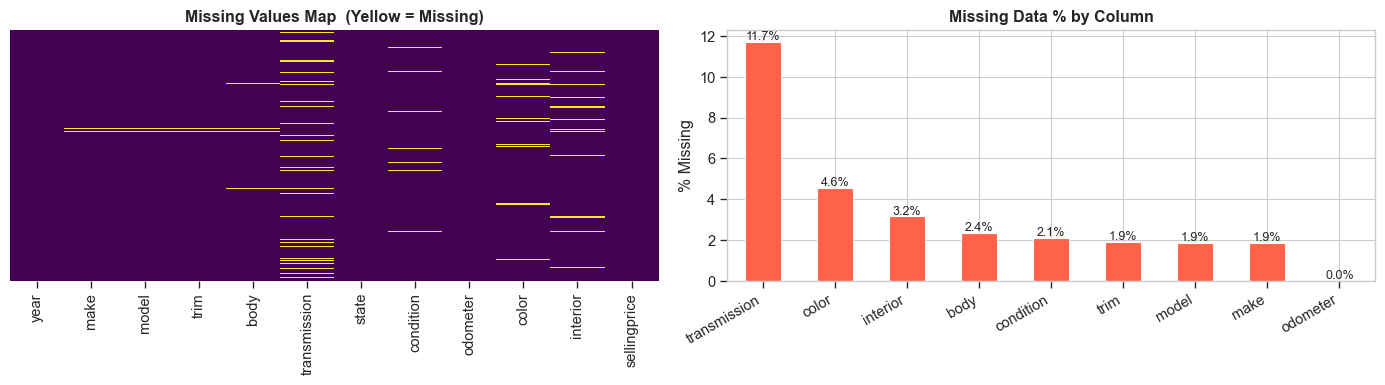

In [2]:
# Missing value density map + column-level null percentages
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Values Map  (Yellow = Missing)', weight='bold')

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
bars = null_pct.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Missing Data % by Column', weight='bold')
axes[1].set_ylabel('% Missing')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.1),
                     ha='center', fontsize=9)
plt.tight_layout(); plt.show()


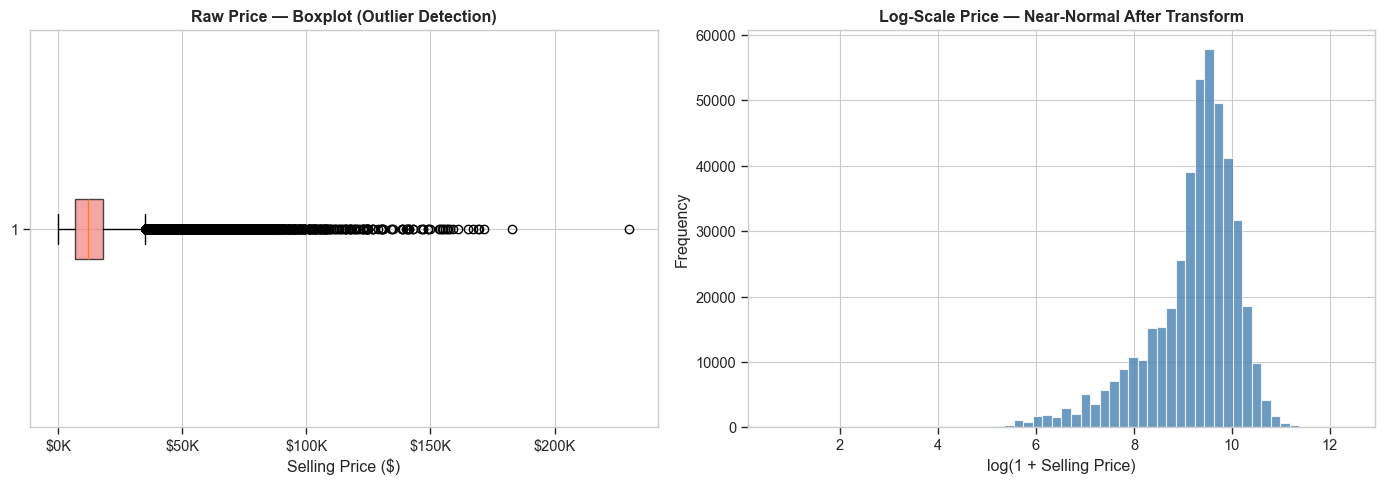

  > $ 80,000 :   377 rows (0.084%)
  > $100,000 :   127 rows (0.028%)
  > $110,000 :    81 rows (0.018%)
  > $120,000 :    59 rows (0.013%)
  > $150,000 :    17 rows (0.004%)


In [3]:
# Selling price distribution — establish outlier boundaries before removing anything
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['sellingprice'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7))
axes[0].set_title('Raw Price — Boxplot (Outlier Detection)', weight='bold')
axes[0].set_xlabel('Selling Price ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[1].hist(np.log1p(df['sellingprice']), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Scale Price — Near-Normal After Transform', weight='bold')
axes[1].set_xlabel('log(1 + Selling Price)'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

for thresh in [80000, 100000, 110000, 120000, 150000]:
    n = (df['sellingprice'] > thresh).sum()
    print(f'  > ${thresh:>7,} : {n:>5,} rows ({n/len(df)*100:.3f}%)')


In [4]:
# Body type case inconsistency — same category recorded under different cases
raw_body_uniques   = df['body'].nunique()
clean_body_uniques = df['body'].str.lower().str.strip().nunique()

print(f'Unique body values — raw: {raw_body_uniques}  |  after lowercase: {clean_body_uniques}')
print(f'Case normalisation eliminates {raw_body_uniques - clean_body_uniques} duplicate categories.')
print()

# Show a few examples
mixed = df['body'].value_counts()
for val in ['Sedan', 'SUV', 'Hatchback', 'Minivan', 'Coupe', 'Convertible']:
    upper_n = (df['body'] == val).sum()
    lower_n = (df['body'] == val.lower()).sum()
    if lower_n > 0:
        print(f'  "{val}": {upper_n:>6,} rows   "{val.lower()}": {lower_n:>6,} rows  → same category')


Unique body values — raw: 84  |  after lowercase: 45
Case normalisation eliminates 39 duplicate categories.

  "Sedan": 159,574 rows   "sedan": 33,574 rows  → same category
  "SUV": 95,363 rows   "suv": 19,587 rows  → same category
  "Hatchback": 17,023 rows   "hatchback":  3,929 rows  → same category
  "Minivan": 17,080 rows   "minivan":  3,344 rows  → same category
  "Coupe": 11,766 rows   "coupe":  2,497 rows  → same category
  "Convertible":  6,898 rows   "convertible":  1,453 rows  → same category


---
## Section 2 — Data Cleaning & Wrangling

**Critical rule:** The train/val split occurs at Step 3, before any imputation statistics are computed. 
All lookup tables are derived from the training set only and applied to both sets. This prevents data leakage.

| Step | Action | Justification |
|------|--------|---------------|
| 1 | Normalise string casing | Body type has 84 pseudo-unique values collapsing to 45 real categories |
| 2 | Global outlier removal | Prices below $500 are data errors; above $120K are exotic collector cars (59 rows) whose prices are driven by provenance, not our features |
| 3 | Group-based IQR outlier removal | Catches model-specific anomalies invisible to global thresholds — e.g. a Chrysler 200 listed at $41K |
| **4** | **Train / Val split** | **Before any statistics are computed** |
| 5 | Impute `condition` | Numeric — median per body type from training data only |
| 6 | Impute `odometer` | Numeric — median from training data only |
| 7 | Fill missing categoricals | `transmission`, `color`, `interior`, `make`, `model`, `trim`, `body` → `'unknown'` |
| 8 | Convert to `category` dtype | Lets LightGBM use its native categorical split algorithm |


In [5]:
df_raw = df.copy()

# Step 1 - Normalise string casing (deterministic, no leakage)
str_cols = ['body','make','model','trim','color','interior','transmission','state']
for col in str_cols:
    df[col] = df[col].str.lower().str.strip()


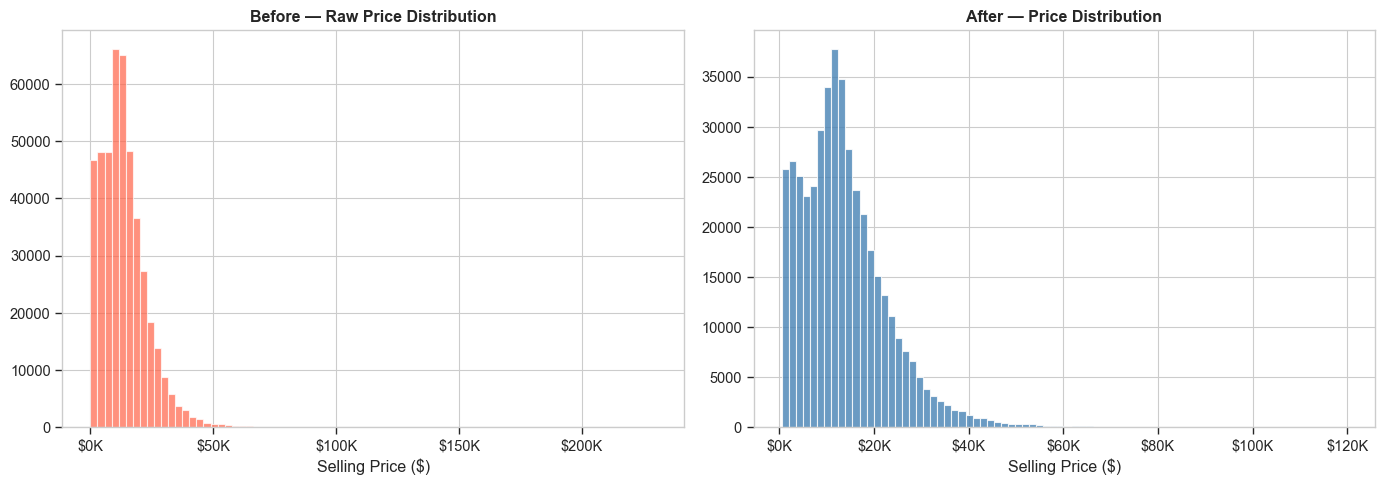

Global outlier removal: 447,048 → 442,151  (removed 4,897 rows)


In [6]:
# Step 2 - Global outlier removal
# Floor $500: prices below this are data entry errors, not real transactions.
# Ceiling $120K: above this threshold only 59 rows remain - exotic collector cars
# (Rolls-Royce Ghost, Ferrari California, Lamborghini Gallardo) whose prices are
# driven by provenance and collector demand rather than the features in our dataset.
# Odometer > 300K: implausible mileage, likely sensor error or placeholder value.
before = len(df)

df = df[(df['sellingprice'] >= 500) & (df['sellingprice'] <= 120000)]
df = df[df['odometer'].isna() | (df['odometer'] <= 300000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_raw['sellingprice'], bins=80, color='tomato', alpha=0.7, edgecolor='white')
axes[0].set_title('Before — Raw Price Distribution', weight='bold')
axes[0].set_xlabel('Selling Price ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].hist(df['sellingprice'], bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('After — Price Distribution', weight='bold')
axes[1].set_xlabel('Selling Price ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout(); plt.show()

print(f'Global outlier removal: {before:,} → {len(df):,}  (removed {before-len(df):,} rows)')


In [7]:
# Step 3 — Train / Val split
# All imputation statistics from this point are computed on df_train only.
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f'Train: {len(df_train):,}  |  Val: {len(df_val):,}')


Train: 353,720  |  Val: 88,431


In [8]:
# Step 4 — Group-based IQR outlier removal (TRAIN SET ONLY)
# Global thresholds miss model-specific nuance (e.g., $30k is normal for a truck, high for a sedan).
grp   = df_train.groupby(['make','model','year'])['sellingprice']
q1    = grp.transform('quantile', 0.25)
q3    = grp.transform('quantile', 0.75)
iqr   = q3 - q1
gsize = grp.transform('count')

# Only apply to groups with 10+ cars, use 2.5 IQR for a wider, safer net
apply  = gsize >= 10
lb, ub = q1 - 2.5 * iqr, q3 + 2.5 * iqr
is_outlier = apply & ((df_train['sellingprice'] < lb) | (df_train['sellingprice'] > ub))

df_train = df_train[~is_outlier].reset_index(drop=True)
print(f"Dropped {is_outlier.sum()} contextual outliers from training set.")

Dropped 2823 contextual outliers from training set.


In [9]:
# Steps 5–6 — Numeric imputation (statistics from training set only)

# Condition: median per body type — body-level grouping preserves more signal
# than a global median since SUV condition scores differ from sedan condition scores.
cond_lookup  = df_train.groupby('body')['condition'].median().to_dict()
global_cond  = float(df_train['condition'].median())

# Odometer: global median — missingness is random (only 69 nulls), no body-level pattern.
odo_median = float(df_train['odometer'].median())

def impute_numeric(dset):
    dset = dset.copy()
    dset['condition'] = dset.apply(
        lambda r: cond_lookup.get(r['body'], global_cond)
                  if pd.isna(r['condition']) else r['condition'], axis=1)
    dset['condition'] = dset['condition'].fillna(global_cond)
    dset['odometer']  = dset['odometer'].fillna(odo_median)
    return dset

df_train = impute_numeric(df_train)
df_val   = impute_numeric(df_val)


In [10]:
# Step 7 — Fill missing categoricals with 'unknown'
# Missing transmission, color, interior are not imputed with statistics —
# 'unknown' is treated as a legitimate category. A car with missing color
# at auction may genuinely signal damage or repaint; the model can learn this.

cat_fill_cols = ['transmission','color','interior','make','model','trim','body']
for dset in [df_train, df_val]:
    for col in cat_fill_cols:
        dset[col] = dset[col].fillna('unknown')


In [11]:
# Step 8 — Convert string columns to pandas category dtype
# LightGBM detects category dtype and uses its native categorical split algorithm
# (optimal partitioning) instead of treating integer codes as ordinal values.
# Val set categories are aligned to training categories — unseen values default to NaN,
# which LightGBM handles natively.

from pandas import CategoricalDtype

plain_cat_cols = ['make','model','body','transmission','color','interior']

for col in plain_cat_cols:
    df_train[col] = df_train[col].astype('category')
    df_val[col]   = pd.Categorical(df_val[col],
                                    categories=df_train[col].cat.categories)

# condition_bucket is built later in Section 4 after car_age is available.
# state_region is built in Section 4 from the state column.

# Save category mappings — needed by the agent for single-row inference
cat_categories = {col: df_train[col].cat.categories.tolist() for col in plain_cat_cols}

assert df_train.isnull().sum().sum() == 0, 'Nulls remain in training set!'

print('=== CLEANING SUMMARY ===')
print(f'  Raw rows               : {len(df_raw):>8,}')
print(f'  After global removal   : {len(df_raw) - (len(df_raw)-len(df)):>8,}')
print(f'  After group IQR removal: {len(df):>8,}')
print(f'  Train rows             : {len(df_train):>8,}')
print(f'  Val rows               : {len(df_val):>8,}')
print(f'  Remaining nulls        : {df_train.isnull().sum().sum():>8}')


=== CLEANING SUMMARY ===
  Raw rows               :  447,048
  After global removal   :  442,151
  After group IQR removal:  442,151
  Train rows             :  350,897
  Val rows               :   88,431
  Remaining nulls        :        0


---
## Section 3 — Analytical EDA

All EDA is performed on `df_eda`, a copy of the training set. 
`df_train` is never modified during this section.

| # | Analysis | Feature Justified |
|---|----------|-------------------|
| 1 | Depreciation curves by body type | `car_age` × `body` interaction |
| 2 | Condition score — non-linear price collapse | Unequal `condition_bucket` bins |
| 3 | Usage intensity vs raw odometer | Include `usage_intensity` alongside `log_odometer` |
| 4 | Transmission × body type heatmap | `body_transmission` interaction feature |
| 5 | Make value residual *(unique)* | Target encoding needed for `trim`; `make`/`model` as category is justified |


In [12]:
df_eda = df_train.copy()
max_year_eda = int(df_eda['year'].max())
df_eda['car_age'] = (max_year_eda - df_eda['year'] + 1).clip(lower=1)
# Convert category back to string for easier EDA operations
for col in ['make','model','body','transmission','color','interior']:
    df_eda[col] = df_eda[col].astype(str)


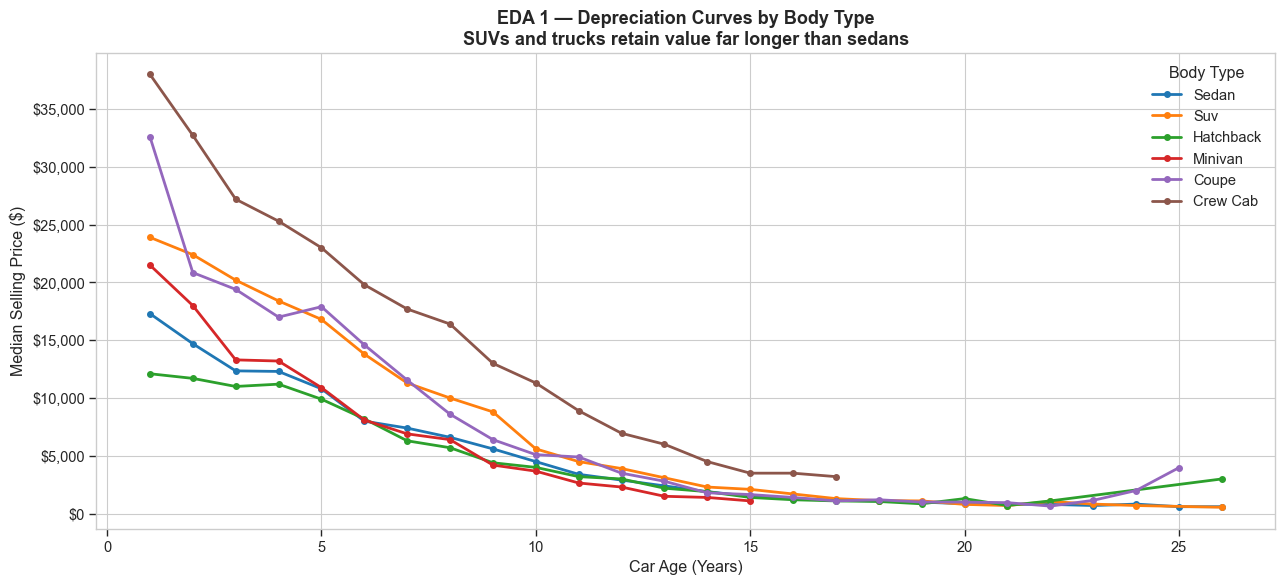

In [13]:
# EDA 1 — Depreciation Curves by Body Type
top_bodies = df_eda['body'].value_counts().head(6).index
depr = (df_eda[df_eda['body'].isin(top_bodies)]
          .groupby(['body','car_age'])['sellingprice'].median().reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
for i, body in enumerate(top_bodies):
    sub = depr[depr['body'] == body]
    ax.plot(sub['car_age'], sub['sellingprice'], marker='o', ms=4, linewidth=2,
            label=body.title(), color=sns.color_palette('tab10', 6)[i])
ax.set_title('EDA 1 — Depreciation Curves by Body Type\n'
             'SUVs and trucks retain value far longer than sedans', weight='bold', fontsize=13)
ax.set_xlabel('Car Age (Years)'); ax.set_ylabel('Median Selling Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(title='Body Type'); plt.tight_layout(); plt.show()


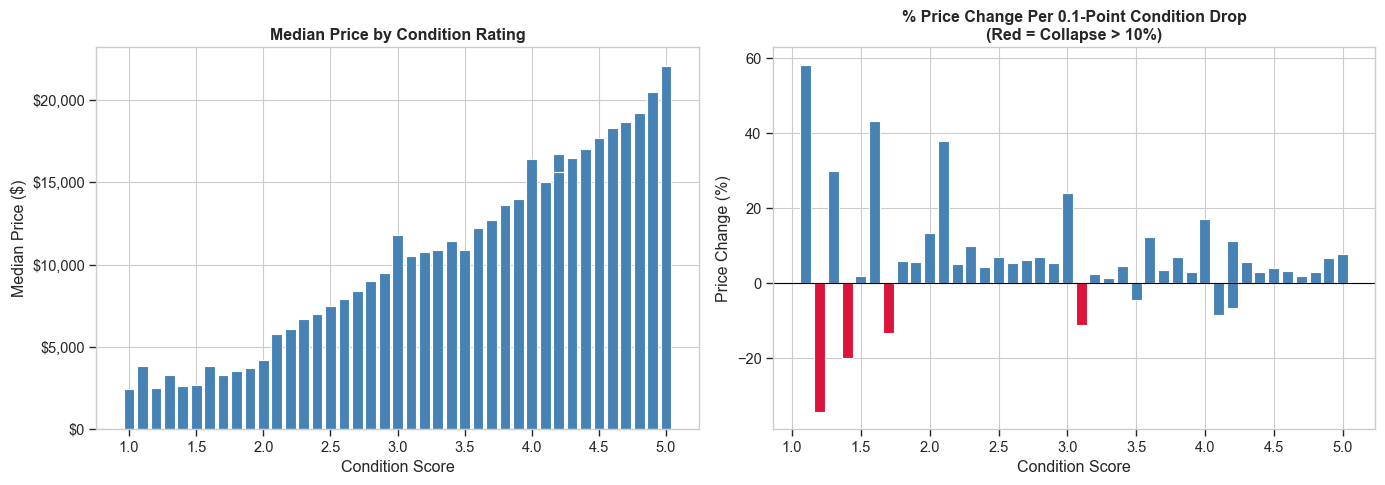

In [14]:
# EDA 2 — Condition Rating: Non-Linear Price Collapse
cond_price = df_eda.groupby('condition')['sellingprice'].median().reset_index()
cond_price['pct_drop'] = cond_price['sellingprice'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cond_price['condition'], cond_price['sellingprice'],
            color='steelblue', edgecolor='white', width=0.08)
axes[0].set_title('Median Price by Condition Rating', weight='bold')
axes[0].set_xlabel('Condition Score'); axes[0].set_ylabel('Median Price ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

colors = cond_price['pct_drop'].iloc[1:].apply(lambda x: 'crimson' if x < -10 else 'steelblue')
axes[1].bar(cond_price['condition'].iloc[1:], cond_price['pct_drop'].iloc[1:],
            color=colors, edgecolor='white', width=0.08)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('% Price Change Per 0.1-Point Condition Drop\n(Red = Collapse > 10%)', weight='bold')
axes[1].set_xlabel('Condition Score'); axes[1].set_ylabel('Price Change (%)')
plt.tight_layout(); plt.show()


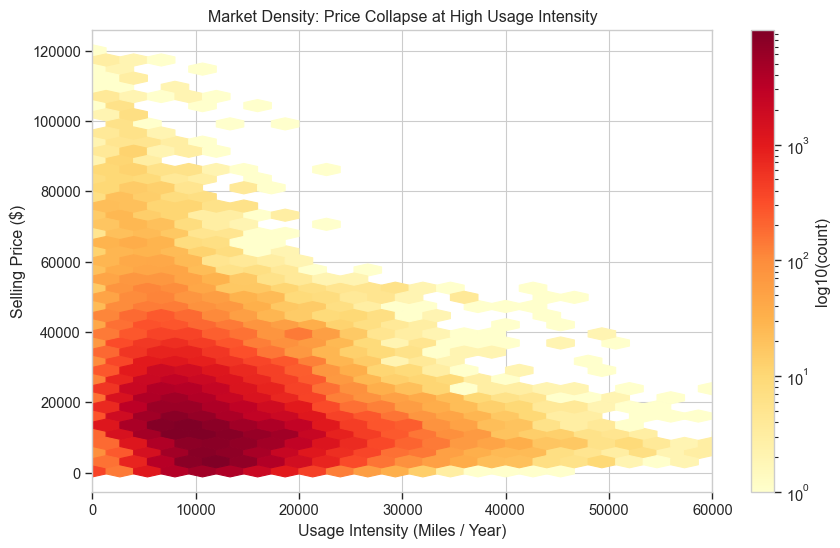

In [15]:
# EDA 3 — Market Density: Usage Intensity vs Price

# 1. Calculate a exploratory metric for usage intensity
temp_max_year = df_eda['year'].max()
df_eda['temp_age'] = (temp_max_year - df_eda['year'] + 1).clip(lower=1)
df_eda['temp_usage_intensity'] = df_eda['odometer'] / df_eda['temp_age']

# 2. Plot the Hexbin Density Map
plt.figure(figsize=(10, 6))
hb = plt.hexbin(df_eda['temp_usage_intensity'], df_eda['sellingprice'], 
                gridsize=40, cmap='YlOrRd', bins='log', mincnt=1)

plt.colorbar(hb, label='log10(count)')
plt.xlabel('Usage Intensity (Miles / Year)')
plt.ylabel('Selling Price ($)')
plt.title('Market Density: Price Collapse at High Usage Intensity')

plt.xlim(0, 60000) 
plt.show()

# Conclusion: The density plot shows a massive concentration of value lost when cars exceed 
# 15,000 miles per year. This heavily justifies formally engineering 'usage_intensity' 
# and 'car_age' as distinct features.

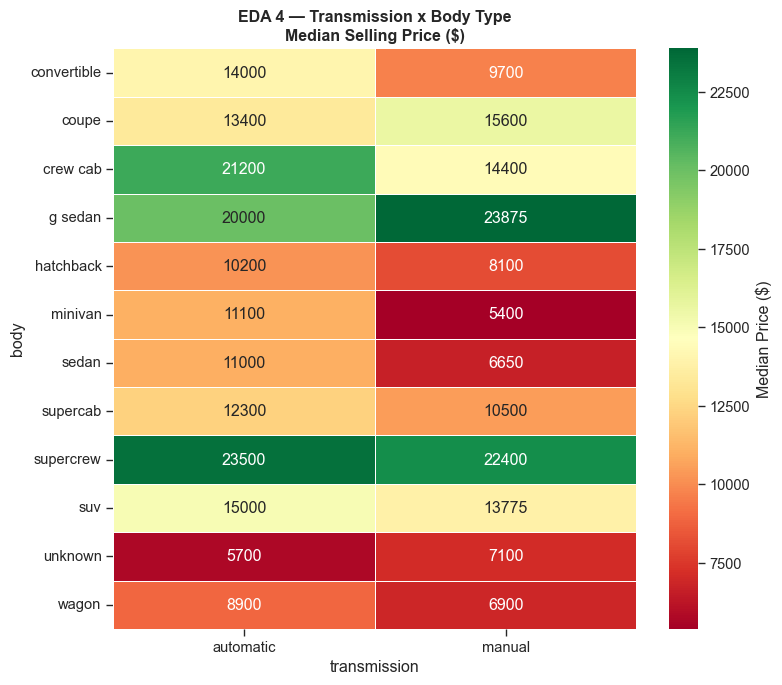

Manual vs Automatic premium (%) by body type:
body
unknown      24.561404
g sedan      19.375000
coupe        16.417910
supercrew    -4.680851
suv          -8.166667
supercab    -14.634146
hatchback   -20.588235
wagon       -22.471910


In [16]:
# EDA 4 — Transmission x Body Type Heatmap
pivot = df_eda.groupby(['body','transmission'])['sellingprice'].median().unstack()
top_b = df_eda['body'].value_counts().head(12).index
pivot_top = pivot.loc[pivot.index.isin(top_b)].dropna(how='all')

fig, ax = plt.subplots(figsize=(8, 7))
heat_data = pivot_top[['automatic','manual']].dropna()
sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar_kws={'label':'Median Price ($)'})
ax.set_title('EDA 4 — Transmission x Body Type\nMedian Selling Price ($)', weight='bold')
plt.tight_layout(); plt.show()

if 'manual' in pivot_top.columns and 'automatic' in pivot_top.columns:
    prem = ((pivot_top['manual'] - pivot_top['automatic']) / pivot_top['automatic'] * 100).dropna()
    print('Manual vs Automatic premium (%) by body type:')
    print(prem.sort_values(ascending=False).head(8).to_string())


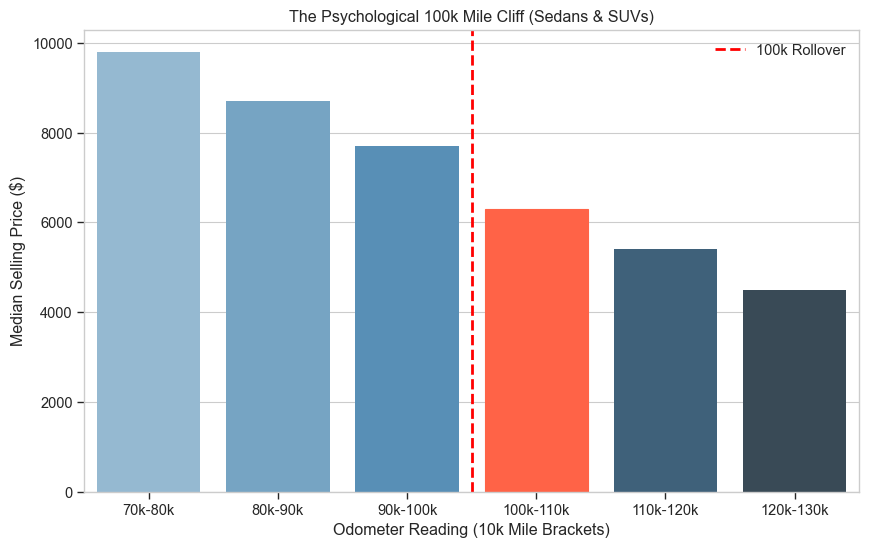

Month-over-Month Price Drops by Mileage Bracket:
  mileage_bracket   pct_drop
1         80k-90k -11.224490
2        90k-100k -11.494253
3       100k-110k -18.181818
4       110k-120k -14.285714
5       120k-130k -16.666667


In [17]:
# EDA 5 — The Psychological Mileage Cliff
# Do human bidders artificially tank a car's value when the odometer hits 6 digits?

# Step 1: Filter for standard commuter cars (Sedans & SUVs) to control for noise
df_psy = df_eda[df_eda['body'].isin(['sedan', 'suv'])].copy()

# Step 2: Zoom in specifically on the 70,000 to 130,000 mile range
df_psy = df_psy[(df_psy['odometer'] >= 70000) & (df_psy['odometer'] < 130000)].copy()

# Step 3: Create 10k mile bins
bins = [70000, 80000, 90000, 100000, 110000, 120000, 130000]
labels = ['70k-80k', '80k-90k', '90k-100k', '100k-110k', '110k-120k', '120k-130k']
df_psy['mileage_bracket'] = pd.cut(df_psy['odometer'], bins=bins, labels=labels, right=False)

# Step 4: Calculate the median price drop across these brackets
cliff_data = df_psy.groupby('mileage_bracket')['sellingprice'].median().reset_index()
cliff_data['pct_drop'] = cliff_data['sellingprice'].pct_change() * 100

# Step 5: Plot the psychological drop
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='mileage_bracket', y='sellingprice', data=cliff_data, palette='Blues_d')

# Highlight the 100k cliff in red for visual impact
bars.patches[3].set_color('tomato') 

plt.title('The Psychological 100k Mile Cliff (Sedans & SUVs)')
plt.xlabel('Odometer Reading (10k Mile Brackets)')
plt.ylabel('Median Selling Price ($)')
plt.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='100k Rollover')
plt.legend()
plt.show()

# Print the percentage drops to prove the point mathematically
print("Month-over-Month Price Drops by Mileage Bracket:")
print(cliff_data[['mileage_bracket', 'pct_drop']].dropna())

---
## Section 4 — Feature Engineering

| Feature | Formula | Decision |
|---------|---------|----------|
| `car_age` | `max_year − year + 1` | Dynamic `max_year` from training data prevents temporal anchor crash |
| `log_odometer` | `log(1 + odometer)` | Right-skewed; raw odometer excluded from model |
| `usage_intensity` | `odometer / car_age` | Clipped at train 99th percentile |
| `condition_bucket` | 4-bin cut | Unequal bins capture non-linear price cliff from EDA 2 |
| `body_transmission` | `body + '_' + transmission` | Interaction premium is body-dependent (EDA 4) |
| `state_region` | map 38 states → 6 regions | Reduces cardinality while preserving geographic signal |
| `trim` | OOF target encoding | 1902 unique values — too high for native LightGBM categorical |


### Cardinality Audit — Encoding Strategy per Column

| Column | Unique Values | Strategy | Reason |
|--------|--------------|----------|--------|
| `make` | 93 | `category` dtype | Within LightGBM native categorical sweet spot |
| `model` | 954 | `category` dtype | Try native first; target encode if unsatisfactory |
| `trim` | 1,902 | OOF Target Encoding | Exceeds reliable native categorical threshold |
| `body` | 45 | `category` dtype (post-normalise) | Low cardinality, perfect for native splits |
| `transmission` | 2 + unknown | `category` dtype | Trivially low cardinality |
| `state` → `state_region` | 38 → 6 | `category` dtype | Region mapping reduces noise |
| `color` | ~30 | `category` dtype | Manageable cardinality |
| `interior` | ~20 | `category` dtype | Manageable cardinality |
| `condition` | continuous | numeric (imputed) | Numeric feature, NaN already handled |
| `odometer` | continuous | numeric → `log_odometer` | Log-transformed; raw dropped |


In [18]:
# Dynamic max_year from training data only
max_year = int(df_train['year'].max())

region_map = {
    'ct':'northeast','ma':'northeast','me':'northeast','nh':'northeast',
    'nj':'northeast','ny':'northeast','pa':'northeast','ri':'northeast','vt':'northeast',
    'al':'southeast','ar':'southeast','fl':'southeast','ga':'southeast','ky':'southeast',
    'la':'southeast','ms':'southeast','nc':'southeast','sc':'southeast','tn':'southeast',
    'va':'southeast','wv':'southeast','il':'midwest','in':'midwest','ia':'midwest',
    'ks':'midwest','mi':'midwest','mn':'midwest','mo':'midwest','ne':'midwest',
    'nd':'midwest','oh':'midwest','sd':'midwest','wi':'midwest',
    'az':'southwest','nm':'southwest','ok':'southwest','tx':'southwest',
    'co':'west','id':'west','mt':'west','nv':'west','or':'west',
    'ut':'west','wa':'west','wy':'west','ca':'west','hi':'west',
    'ab':'other','ns':'other','on':'other','qc':'other','pr':'other'
}

for dset in [df_train, df_val]:
    dset['car_age']           = (max_year - dset['year'] + 1).clip(lower=1)
    dset['log_odometer']      = np.log1p(dset['odometer'])
    dset['body_transmission'] = dset['body'].astype(str) + '_' + dset['transmission'].astype(str)
    dset['state_region']      = dset['state'].map(region_map).fillna('other')

# usage_intensity: clip at 99th percentile of training data
ui_cap = float((df_train['odometer'] / df_train['car_age']).quantile(0.99))
for dset in [df_train, df_val]:
    dset['usage_intensity'] = (dset['odometer'] / dset['car_age']).clip(upper=ui_cap)

print(f'max_year : {max_year}')
print(f'ui_cap   : {ui_cap:,.0f} miles/year (train 99th pct)')


max_year : 2015
ui_cap   : 28,190 miles/year (train 99th pct)


In [19]:
# condition_bucket — ordered categorical (unequal bins from EDA 2)
from pandas import CategoricalDtype

cond_dtype = CategoricalDtype(
    categories=['unknown','poor','fair','good','excellent'],
    ordered=True
)

for dset in [df_train, df_val]:
    dset['condition_bucket'] = pd.cut(
        dset['condition'],
        bins=[0, 2.0, 3.0, 4.0, 5.1],
        labels=['poor','fair','good','excellent']
    )
    dset['condition_bucket'] = (dset['condition_bucket']
                                  .cat.add_categories('unknown')
                                  .fillna('unknown')
                                  .astype(cond_dtype))

# state_region and body_transmission to category
for col in ['state_region','body_transmission']:
    df_train[col] = df_train[col].astype('category')
    df_val[col]   = pd.Categorical(df_val[col], categories=df_train[col].cat.categories)

# Add state_region to cat_categories for agent
cat_categories['state_region']      = df_train['state_region'].cat.categories.tolist()
cat_categories['body_transmission'] = df_train['body_transmission'].cat.categories.tolist()
cat_categories['condition_bucket']  = list(cond_dtype.categories)


In [20]:
# OOF Target Encoding for trim only (1902 unique values)
from sklearn.model_selection import KFold

y_train = np.log1p(df_train['sellingprice'])
y_val   = np.log1p(df_val['sellingprice'])

def oof_target_encode(train_s, train_y, val_s, smoothing=20, n_splits=5):
    global_mean = train_y.mean()
    oof         = pd.Series(np.nan, index=train_s.index)
    kf          = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_lkps   = []
    for tr, vl in kf.split(train_s):
        fx, fy = train_s.iloc[tr], train_y.iloc[tr]
        stats  = fy.groupby(fx).agg(['mean','count'])
        sm     = (stats['count']*stats['mean'] + smoothing*global_mean) / (stats['count']+smoothing)
        lkp    = sm.to_dict()
        fold_lkps.append(lkp)
        oof.iloc[vl] = train_s.iloc[vl].map(lkp).fillna(global_mean)
    all_keys  = set().union(*[d.keys() for d in fold_lkps])
    final_lkp = {k: np.mean([d[k] for d in fold_lkps if k in d]) for k in all_keys}
    return oof.fillna(global_mean), val_s.map(final_lkp).fillna(global_mean), final_lkp, global_mean

df_train['trim_te'], df_val['trim_te'], trim_lookup, trim_global = \
    oof_target_encode(df_train['trim'].astype(str), y_train, df_val['trim'].astype(str))

print(f'trim OOF target encoding: {len(trim_lookup):,} categories')


trim OOF target encoding: 1,737 categories


Features (12): ['make', 'model', 'body', 'color', 'interior', 'car_age', 'log_odometer', 'body_transmission', 'state_region', 'usage_intensity', 'condition_bucket', 'trim_te']
Nulls — train: 0  val: 23


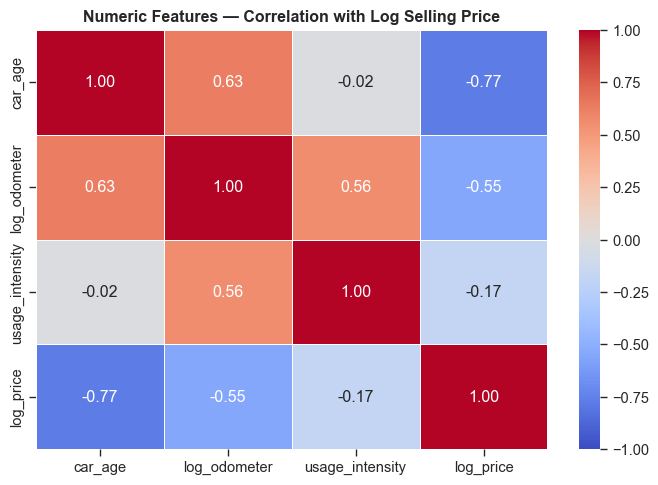

In [21]:
# Final feature matrix
drop_cols = set([
    'sellingprice','year','trim','state','odometer',  # raw columns
    'transmission', 'condition'                       # captured in body_transmission
])

feature_cols = [c for c in df_train.columns if c not in drop_cols]
X_train_f    = df_train[feature_cols].copy()
X_val_f      = df_val[feature_cols].copy()

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Nulls — train: {X_train_f.isnull().sum().sum()}  val: {X_val_f.isnull().sum().sum()}')

# Correlation heatmap — numeric features only
num_feats = ['car_age','log_odometer','usage_intensity']
corr_df = X_train_f[num_feats].copy()
corr_df['log_price'] = y_train
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Numeric Features — Correlation with Log Selling Price', weight='bold')
plt.tight_layout(); plt.show()


---
## Section 5 — Model Training & Hyperparameter Tuning

**Model:** LightGBM Regressor. Tree-based regression; handles `category` dtype natively via 
optimal partition splits; no feature scaling required; efficient on 350K+ rows.

**Target transform:** `log1p(sellingprice)` — normalises right-skewed price distribution. 
All predictions reversed with `expm1()`.

**Validation:** Random 80/20 split. No temporal dependency in auction records.

**Tuning:** `RandomizedSearchCV` with 3-fold CV on a 30% sample (for speed), then full retrain 
on all training data with best parameters.

**Prediction model** — Standard Regression (MSE):
We use a standard Mean Squared Error (MSE) objective to predict the true average market value of each vehicle.


In [22]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error
import joblib

# Baseline — all default hyperparameters
baseline = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
baseline.fit(X_train_f, y_train)
y_val_actual  = np.expm1(y_val)
baseline_pred = np.expm1(baseline.predict(X_val_f))
baseline_rmse = np.sqrt(mean_squared_error(y_val_actual, baseline_pred))
print(f'Baseline RMSE (default params): ${baseline_rmse:,.2f}')


Baseline RMSE (default params): $2,551.04


In [23]:
# Hyperparameter search on 30% sample (results should be similar according to LLN)
idx = np.random.RandomState(42).choice(len(X_train_f), size=int(0.3*len(X_train_f)), replace=False)
Xs, ys = X_train_f.iloc[idx], y_train.iloc[idx]

param_dist = {
    'n_estimators'    : [400, 600, 800],
    'learning_rate'   : [0.03, 0.05, 0.1],
    'max_depth'       : [4, 6, 8],
    'num_leaves'      : [31, 63, 127],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [20, 30, 50],
    'reg_alpha'       : [0.0, 0.1, 0.5],
    'reg_lambda'      : [0.0, 0.1, 1.0]
}

search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist, n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(Xs, ys)
print('Best params:', search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [24]:
# Full retrain with best params — MSE and Quantile models
best_params = search.best_params_

tuned_mse = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **best_params)
tuned_mse.fit(X_train_f, y_train)
tuned_mse_pred = np.expm1(tuned_mse.predict(X_val_f))
tuned_mse_rmse = np.sqrt(mean_squared_error(y_val_actual, tuned_mse_pred))

print('=' * 55)
print('           MODEL COMPARISON TABLE')
print('=' * 55)
print(f'  {"Model":<33} {"Val RMSE":>12}')
print('-' * 55)
print(f'  {"Baseline (default)":<33} ${baseline_rmse:>10,.2f}')
print(f'  {"Tuned LightGBM ":<33} ${tuned_mse_rmse:>10,.2f}')
print(f'  {"MSE improvement over baseline":<33} {(baseline_rmse-tuned_mse_rmse)/baseline_rmse*100:>9.2f}%')
print('=' * 55)

# Check for Overfitting
train_pred = np.expm1(tuned_mse.predict(X_train_f))
y_train_actual = np.expm1(y_train)

from sklearn.metrics import mean_squared_error
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
print(f"Training RMSE:   ${train_rmse:,.2f}")


           MODEL COMPARISON TABLE
  Model                                 Val RMSE
-------------------------------------------------------
  Baseline (default)                $  2,551.04
  Tuned LightGBM                    $  2,159.61
  MSE improvement over baseline         15.34%
Training RMSE:   $1,856.30


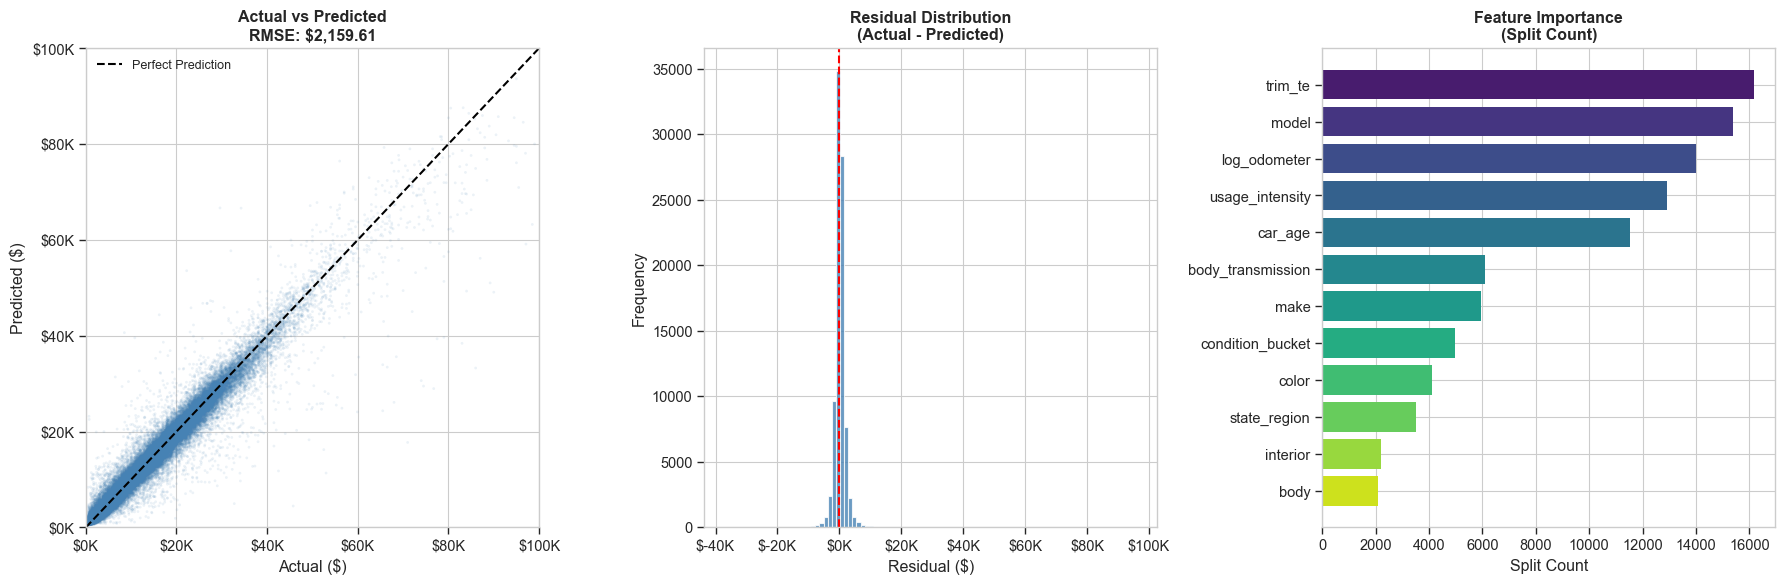

In [25]:
# Evaluation plots — production Quantile model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

lims = [0, 100000]
axes[0].scatter(y_val_actual, tuned_mse_pred, alpha=0.1, color='steelblue', s=4, edgecolors='none')
axes[0].plot(lims, lims, 'k--', lw=1.5, label='Perfect Prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title(f'Actual vs Predicted\nRMSE: ${tuned_mse_rmse:,.2f}', weight='bold')
axes[0].set_xlabel('Actual ($)'); axes[0].set_ylabel('Predicted ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend(fontsize=9)

residuals = y_val_actual.values - tuned_mse_pred
axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residual Distribution\n(Actual - Predicted)', weight='bold')
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

feat_names = [str(c) for c in X_train_f.columns]
imp_df = pd.DataFrame({'Feature': feat_names,
                        'Importance': tuned_mse.feature_importances_
                       }).sort_values('Importance', ascending=False)
axes[2].barh(imp_df['Feature'], imp_df['Importance'],
             color=sns.color_palette('viridis', len(imp_df)))
axes[2].invert_yaxis()
axes[2].set_title('Feature Importance\n(Split Count)', weight='bold')
axes[2].set_xlabel('Split Count')

plt.tight_layout(); plt.show()


---
## Section 6 — Save Artifacts

The `encoders` dictionary bundles everything the agent needs at single-row inference time. 
Nothing is fitted inside the agent — all statistics come from here.


In [26]:
encoders = {
    # Category mappings - required for single-row category dtype conversion in agent
    'cat_categories' : cat_categories,
    'cond_dtype_cats': list(cond_dtype.categories),

    # OOF target encoding for trim
    'trim_lookup'    : trim_lookup,
    'trim_global'    : trim_global,

    # Numeric imputation (from training set only)
    'cond_lookup'    : cond_lookup,
    'global_cond'    : global_cond,
    'odo_median'     : odo_median,

    # Feature engineering constants
    'max_year'       : max_year,
    'ui_cap'         : ui_cap,
    'region_map'     : region_map,

    # Feature column order - must match training exactly
    'feature_cols'   : feature_cols,

    # Model metadata
    'target_transform': 'log1p',
    'target_inverse'  : 'expm1',
    'model_objective' : 'regression'
}

joblib.dump(tuned_mse,  'model_IronLot.pkl')
joblib.dump(encoders, 'encoders_IronLot.pkl')

print('model_IronLot.pkl    saved')
print('encoders_IronLot.pkl saved')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')


model_IronLot.pkl    saved
encoders_IronLot.pkl saved
Feature columns (12): ['make', 'model', 'body', 'color', 'interior', 'car_age', 'log_odometer', 'body_transmission', 'state_region', 'usage_intensity', 'condition_bucket', 'trim_te']
